In [24]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

## Question 1
Use the Open-Meteo API to fetch Adelaide’s daily temperature data for Winter 2026 (June, July, August) and plot the time series. Identify any obvious trends or seasonality in the data. This data should be utilised for question 2-5 below.

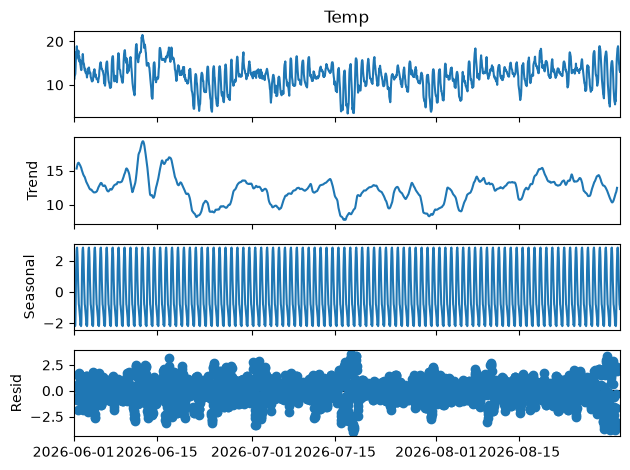

In [25]:
# Setting up for our API request
endpoint = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': -34.9287,   # Latitude for Adelaide
    'longitude': 138.5986,  # Longitude for Adelaide
    'start_date': '2026-06-01',
    'end_date': '2026-08-31',
    'hourly': 'temperature_2m',
    'timezone': 'Australia/Adelaide'
}

# Making request
response = requests.get(endpoint, params=params)
wdata = response.json()

# Extracting relevant data
timestamps = [datetime.fromisoformat(item) for item in wdata['hourly']['time']]
temperatures = wdata['hourly']['temperature_2m']

# Creating a pandas dataframe
wdf = pd.DataFrame({
    'Date': timestamps,
    'Temp': temperatures
})

# Setting date column as index
wdf.set_index('Date', inplace=True)

# Set frequency to hourly
wdf = wdf.asfreq('h')

# Seasonal decomposition
decomp = seasonal_decompose(wdf['Temp'], model='additive', period=24)

# Plotting decomposed components
decomp.plot()
plt.show()

## Question 2
Fit an ARIMA model to the Adelaide daily temperature data for Winter 2026. Use the order (5,1,0) and calculate the training RMSE.

In [26]:
# ARIMA model init and fitting
arima_model = ARIMA(wdf['Temp'], order=(5, 1, 0))
arima_model_fit = arima_model.fit()

# Compute Root Mean Squared Error
train_rmse = np.sqrt((arima_model_fit.resid[1:] ** 2).mean())
print(f'RMSE: {train_rmse}')

RMSE: 0.5833617655583845


## Question 3
Using the Adelaide daily temperature data for Winter 2026, compare the performance of ARIMA models with different orders: (5,1,0), (1,1,1), and (2,1,2). Calculate and compare the training RMSE for each model.

In [27]:
# ARIMA model init and fitting for different orders
orders = [
    (5, 1, 0),
    (1, 1, 1),
    (2, 1, 2)
]

for order in orders:
    arima_model = ARIMA(wdf['Temp'], order=order)
    arima_model_fit = arima_model.fit()

    train_rmse = np.sqrt((arima_model_fit.resid[1:] ** 2).mean())
    print(f'RMSE for order {order}: {train_rmse}')

RMSE for order (5, 1, 0): 0.5833617655583845
RMSE for order (1, 1, 1): 0.5932028581823455
RMSE for order (2, 1, 2): 0.5852650751980312


/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


## Question 4
Perform a 7-step rolling forecast on a hold-out test set using the best ARIMA model from the previous question. Calculate the MAE, MSE, RMSE, and $R^2$ for the rolling forecast.

In [28]:
# Train test split
train, test = wdf['Temp'][:-7], wdf['Temp'][-7:]

# Fit model
arima_model = ARIMA(train, order=(5, 1, 0)).fit()

# Rolling forecast
predictions = []
for t in test:
    predictions.append(arima_model.forecast())
    arima_model = arima_model.append([t], refit=False)

# Compute metrics
print('Mean Absolute Error: ', mean_absolute_error(test, predictions))
print('Mean Squared Error: ', mean_squared_error(test, predictions))
print('Root Mean Squared Error: ', root_mean_squared_error(test, predictions))
print('R^2 Score: ', r2_score(test, predictions))

Mean Absolute Error:  0.5563769483754284
Mean Squared Error:  0.3745561033391023
Root Mean Squared Error:  0.6120098882690559
R^2 Score:  0.7836722175434228


## Question 5
Update the model to include an exogenous variable (e.g., hour of the day). Fit the model and compare its performance with the best Adelaide daily temperature ARIMA model without the exogenous variable.